# to add:
0) if 1e-4 doesn't work consider:
- is the topology-weighted stochastic edge adding accurate?
- are all MOAs known? would assigning th ecorrect proportion as unknown help?
1) relationship between topology, edge weights, etc etc as done in GAMM
2) assessment of forward pass test prediction matching original reasonably well

In [39]:
import os

from tqdm import trange

import json
from typing import List, Literal

import numpy as np
import pandas as pd

import scanpy as sc
import pathlib
import torch
import torch.nn as nn

import matplotlib.pyplot as plt
import seaborn as sns

import sys
sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
from scLEMBAS import preprocess as pp 
from scLEMBAS.model.train import TrainSC
from scLEMBAS.model.scl import SignalingModel
import anndata


sys.path.insert(1, '../../.')
from McCauley_utils import initialize_mod_and_trainer, all_data

sys.path.insert(1, '../../../.') 
from notebook_utils import get_split


In [40]:
seed = 888
data_path = '/home/hmbaghda/orcd/pool/scLEMBAS/analysis'
author = 'McCauley'

n_cores = 30
os.environ["OMP_NUM_THREADS"] = str(1)
os.environ["MKL_NUM_THREADS"] = str(1)
os.environ["OPENBLAS_NUM_THREADS"] = str(1)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(1)
os.environ["NUMEXPR_NUM_THREADS"] = str(1)


In [41]:
(sn_ppis, tf_adata, adata, expr, source_label, target_label, weight_label, 
 stimulation_label, inhibition_label, cat_col, pert_col, ctrl_pert) = all_data

num_stochastic_edges = int(np.round(0.01*sn_ppis.shape[0]))


In [42]:
seed_multiplier = 21234
def load_model(fold, ensemble_idx, bn_weight_l2 = 1e-7, from_trainer = False):
    """Loads the model and training object.

    Two different ways to do so: from pickled training object (larger files) or from model state dict `.pt` file (smaller files to transfer).

    Parameters
    ----------
    fold : int
        fold split
    ensemble_idx : int
        ensemble index
    from_trainer : bool, optional
        whether to load from trainer object or model state dict, by default False
        if False, the training object is not returned
    """
    curr_seed = seed + ensemble_idx + 1 + (seed_multiplier * ensemble_idx * fold)
    
    l2_string = '{:.0E}'.format(bn_weight_l2).replace('E-0', 'E-')
    fn_base = os.path.join(data_path, 'processed', 'pruning_ensembles', '{}_fold{}_l2{}'.format(author, fold, l2_string))
    
    if from_trainer:
        fn_trainer =  os.path.join(fn_base + '_pruning_trainer_actual_ensemble{}.pickle'.format(ensemble_idx))
        trainer = io.read_pickled_object(fn_trainer)
        mod = trainer.mod
    else:
        seed_ = seed + ensemble_idx + 1 + (seed_multiplier * ensemble_idx * fold) if ensemble_idx <= 3 else seed
        mod, trainer = initialize_mod_and_trainer(
            fold = fold, 
            adversarial_penalty = True, 
            randomize = False, 
            num_stochastic_edges = num_stochastic_edges,
            seed = curr_seed, 
        )
        
        fn_mod = os.path.join(fn_base + '_pruning_model_actual_ensemble{}.pt'.format(ensemble_idx))
        mod.load_state_dict(torch.load(fn_mod))
        trainer = None
    return mod, trainer



In [43]:
bn_weight_l2 = 1e-7

In [44]:
def get_edge_weights(fold, ensemble_idx, bn_weight_l2):
    mod, trainer = load_model(fold = fold, ensemble_idx = ensemble_idx, bn_weight_l2 = bn_weight_l2, from_trainer = False)
    
    src, tar = mod.signaling_network.added_edges
    src_real, tar_real = mod.signaling_network.edge_real_edges

    # Extract data
    stochastic_edge_weights = torch.abs(mod.signaling_network.weights[src, tar].detach().cpu().flatten())
    real_edge_weights = torch.abs(mod.signaling_network.weights[src_real, tar_real].detach().cpu().flatten())

    return mod, stochastic_edge_weights, real_edge_weights

learned_weights = []
mod_dict = {}
for fold in range(5):
    for ensemble_idx in trange(5):
        mod, stochastic_edge_weights, real_edge_weights = get_edge_weights(fold, ensemble_idx, bn_weight_l2)
        
        learned_vals = pd.DataFrame(data= {
            'weights': np.concatenate([stochastic_edge_weights.numpy(), real_edge_weights.numpy()]), 
            'edge_type': ['random']*stochastic_edge_weights.size()[0] + ['real']*real_edge_weights.size()[0]
        })
        learned_vals['fold'] = fold
        learned_vals['ensemble_idx'] = ensemble_idx
        
        learned_weights.append(learned_vals)
        mod_dict['fold{}_ensemble{}'.format(fold, ensemble_idx)] = mod
learned_weights = pd.concat(learned_weights)


100%|████████████████████████████████████████████████████████████████████| 5/5 [00:22<00:00,  4.60s/it]


In [18]:
sns.set_context(
    "paper",
    rc={
        "axes.labelsize": 15,
        "axes.titlesize": 16,
        "legend.fontsize": 12,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
    }
)

/tmp/ipykernel_817007/305977632.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


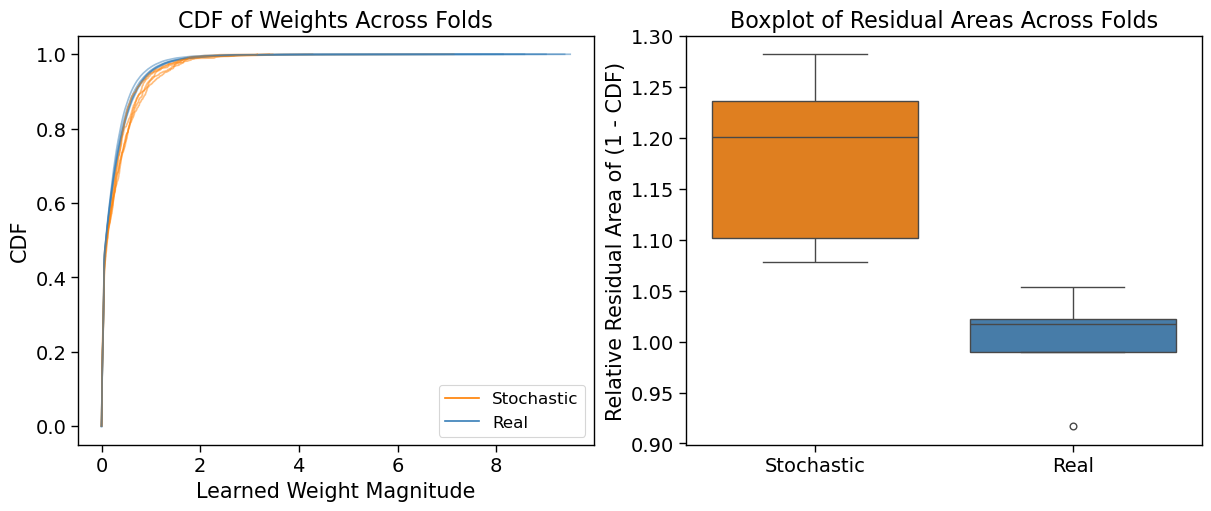

In [19]:
def compute_cdf(x):
    x = np.asarray(x)
    x_sorted = np.sort(x)
    y = np.arange(1, len(x_sorted) + 1, dtype=float) / len(x_sorted)
    return x_sorted, y


# -------------------- SETUP --------------------
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5), constrained_layout=True)

residuals_stochastic = []
residuals_real = []
stoch_color = sns.color_palette('Set1')[4]
real_color = sns.color_palette('Set1')[1]

real_mask = (learned_weights.edge_type == 'real')


# -------------------- CDF PANEL --------------------
j = 0
for fold in range(5):
    fold_mask = (learned_weights.fold == fold)

    x_stoch, y_stoch = compute_cdf(learned_weights[fold_mask & ~real_mask].weights.values)
    x_real, y_real = compute_cdf(learned_weights[fold_mask & real_mask].weights.values)

    sns.lineplot(x=x_stoch, y=y_stoch, ax=ax[j], color=stoch_color, alpha=0.5)
    sns.lineplot(x=x_real, y=y_real, ax=ax[j], color=real_color, alpha=0.5)

    # residual areas
    area_stoc = np.trapz(1 - y_stoch, x_stoch)
    area_real = np.trapz(1 - y_real, x_real)

    residuals_stochastic.append(area_stoc)
    residuals_real.append(area_real)

ax[j].set_xlabel("Learned Weight Magnitude")
ax[j].set_ylabel("CDF")
ax[j].set_title("CDF of Weights Across Folds")

# clean legend (manual to avoid duplicates)
handles = [
    plt.Line2D([0], [0], color=stoch_color, label="Stochastic"),
    plt.Line2D([0], [0], color=real_color, label="Real")
]
ax[j].legend(handles=handles)


# -------------------- BOXPLOT PANEL --------------------
j = 1
mean_real = np.mean(residuals_real)

df_box = pd.DataFrame({
    "value": np.concatenate([
        np.array(residuals_stochastic) / mean_real,
        np.array(residuals_real) / mean_real
    ]),
    "type": ["Stochastic"] * len(residuals_stochastic) +
            ["Real"] * len(residuals_real)
})

sns.boxplot(
    data=df_box,
    x="type",
    y="value",
    palette={"Stochastic": stoch_color, "Real": real_color},
    ax=ax[j]
)

ax[j].set_ylabel("Relative Residual Area of (1 - CDF)")
ax[j].set_xlabel("")
ax[j].set_title("Boxplot of Residual Areas Across Folds")


plt.show()
